# EDA: Talent vs. Motor Language in Scout Strengths

We apply two hand-crafted lexicons to the **strengths column only**, asking:
> *Which positions do scouts describe in terms of god-given athleticism vs. learned skill/technique — and does that relate to grade or second-contract outcomes?*

Using `strengths` instead of `combined_text` removes weakness-section noise: scouts praising
a player's strengths in motor/technique terms is a genuine positive signal, not a critique.

| Score | Captures |
|-------|----------|
| **Talent** | Athletic/physical trait language — explosive, burst, speed, frame, fluid… |
| **Motor** | Skill, technique, character — instinct, footwork, route, consistent, grit… |
| **Ath ratio** | `talent / (talent + motor)` — 1.0 = pure athleticism, 0.0 = pure technique |

## 1. Imports & Controls

In [46]:
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)
nltk.download('omw-1.4',  quiet=True)
warnings.filterwarnings('ignore')

# ── Filters ───────────────────────────────────────────────────────────────────
YEAR_MIN  = 2010
YEAR_MAX  = 2025
GRADE_MAX = 8.5
TARGET    = 'made_it_contract'

## 2. Load & Preprocess — strengths only

In [47]:
df = pd.read_csv('../data/processed/draft_enriched_with_contracts.csv')
df = df[(df['year'] >= YEAR_MIN) & (df['year'] <= YEAR_MAX)].copy()
df = df[df['grade'] <= GRADE_MAX].copy()
df = df.dropna(subset=[TARGET, 'grade', 'Pos_Group', 'strengths']).copy()
df[TARGET] = df[TARGET].astype(int)

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Outcome-leaking phrases stripped before processing
PHRASE_BLOCKLIST = [
    'undrafted free agent', 'practice squad', 'free agent',
    'pro bowl', 'late round', 'make roster', 'rostered',
]

def preprocess(text: str) -> str:
    if not isinstance(text, str) or not text.strip():
        return ''
    text = text.lower()
    for phrase in PHRASE_BLOCKLIST:
        text = text.replace(phrase, ' ')
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = [
        lemmatizer.lemmatize(w)
        for w in text.split()
        if w not in stop_words and len(w) > 1
    ]
    return ' '.join(tokens)

df['strengths_preproc'] = df['strengths'].apply(preprocess)
df = df[df['strengths_preproc'] != ''].copy().reset_index(drop=True)

print(f'Players after filters: {len(df)}')
print(f'Positive rate: {df[TARGET].mean():.1%}')
print(f'\nPer Pos_Group:')
print(df['Pos_Group'].value_counts().to_string())

Players after filters: 5153
Positive rate: 25.1%

Per Pos_Group:
Pos_Group
DB         1005
OL          870
WR          716
EDGE        604
RB          462
DT          452
LB          411
TE          296
QB          221
SPECIAL     116


## 3. Lexicon & Scoring

In [48]:
# ── Word sets ─────────────────────────────────────────────────────────────────
# Talent = something a player IS or is born with (measurable, physical)
# Motor  = something a player DOES or LEARNS (technique, character, mental)
TALENT_WORDS = {
    'athletic', 'athleticism', 'athlete', 'explosive', 'explosion', 'explosiveness',
    'burst', 'speed', 'fast', 'quick', 'quickness', 'agile', 'agility',
    'physical', 'strength', 'powerful', 'power', 'acceleration', 'twitch', 'twitchy',
    'size', 'length', 'frame', 'height', 'wingspan', 'rangy',
    'fluid', 'fluidity', 'bend', 'flexible', 'flexibility',
    'mobile', 'mobility', 'lateral', 'vertical', 'balance', 'hip', 'stride',
    'separation', 'closing', 'elite', 'raw',
    # Receiver / applied athleticism — physical tools, body control, leaping ability
    # (previously uncategorized despite being innate physical traits)
    'jump', 'leap', 'smooth', 'electric',
    'arm', 'radius',       # arm length, catch radius
    'tracking',            # ball tracking / eye-body coordination
    'release',             # quickness off the line of scrimmage
    'contested',           # physical ability to win in traffic
    'crisp',               # sharp, precise cuts (movement quality)
}
MOTOR_WORDS = {
    # character / work ethic
    'motor', 'effort', 'compete', 'competitive', 'relentless', 'hustle',
    'commitment', 'dedicated', 'diligent', 'energy', 'passion',
    'character', 'leadership', 'leader', 'discipline', 'grit',
    'tough', 'toughness', 'aggressive', 'pursuit',
    # mental / awareness
    'instinct', 'aware', 'awareness', 'smart', 'intelligent', 'intelligence',
    'anticipation', 'recognition', 'read', 'understanding',
    'assignment', 'diagnosis', 'preparation',
    # technique / skill execution
    'technique', 'fundamental', 'mechanic', 'execution', 'precision',
    'timing', 'consistent', 'consistency', 'reliable', 'sound',
    'tackle', 'block', 'blocking', 'catch', 'route',
    'hand', 'footwork', 'leverage', 'skill',
}

# ── Smoothing control ─────────────────────────────────────────────────────────
# Additive (Laplace) smoothing for ath_ratio_smooth.
# α=1.0 → Laplace prior (default); α=0.5 → Jeffrey's prior (used in eda_adjectives notebook).
# Set to 0 to recover the original unsmoothed behaviour.
SMOOTH_ALPHA = 1.0

# ── Scoring helpers ───────────────────────────────────────────────────────────
def count_hits(text: str, word_set: set) -> int:
    """Return raw hit count (number of matching words)."""
    return sum(1 for w in text.split() if w in word_set)

def score_text(text: str, word_set: set) -> float:
    """Return proportion of words matching word_set."""
    words = text.split()
    if not words:
        return 0.0
    return sum(1 for w in words if w in word_set) / len(words)

# Raw hit counts (needed for smoothing)
df['talent_hits'] = df['strengths_preproc'].apply(lambda t: count_hits(t, TALENT_WORDS))
df['motor_hits']  = df['strengths_preproc'].apply(lambda t: count_hits(t, MOTOR_WORDS))

# Proportion scores (kept for backward compatibility with downstream cells)
df['talent_score'] = df['strengths_preproc'].apply(lambda t: score_text(t, TALENT_WORDS))
df['motor_score']  = df['strengths_preproc'].apply(lambda t: score_text(t, MOTOR_WORDS))

# Unsmoothed ratio — NaN if both lexicons get zero hits (kept for EDA sections 4–6)
total = df['talent_score'] + df['motor_score']
df['ath_ratio'] = np.where(total > 0, df['talent_score'] / total, np.nan)

# Smoothed ratio — always non-null; shrinks short/sparse texts toward 0.5
denom_smooth = df['talent_hits'] + df['motor_hits'] + 2 * SMOOTH_ALPHA
df['ath_ratio_smooth'] = (df['talent_hits'] + SMOOTH_ALPHA) / denom_smooth

print('Score coverage (% with score > 0):')
print(f'  Talent: {(df["talent_score"] > 0).mean():.1%}')
print(f'  Motor:  {(df["motor_score"]  > 0).mean():.1%}')
print(f'  Both:   {((df["talent_score"] > 0) & (df["motor_score"] > 0)).mean():.1%}')
print(f'  Ath ratio non-null: {df["ath_ratio"].notna().mean():.1%}')
print(f'  Ath ratio smooth (always non-null): 100.0%  (SMOOTH_ALPHA={SMOOTH_ALPHA})')
print(f'\nMean scores overall:')
print(df[['talent_score', 'motor_score', 'ath_ratio', 'ath_ratio_smooth']].mean().round(4).to_string())

Score coverage (% with score > 0):
  Talent: 95.0%
  Motor:  94.8%
  Both:   90.3%
  Ath ratio non-null: 99.6%
  Ath ratio smooth (always non-null): 100.0%  (SMOOTH_ALPHA=1.0)

Mean scores overall:
talent_score        0.0872
motor_score         0.0749
ath_ratio           0.5286
ath_ratio_smooth    0.5237


## 3b. Text Length Diagnostics — Why Smoothing Is Needed

Short scouting reports produce extreme, unreliable ratios (e.g. 5 athletic hits, 0 motor hits → ratio = 1.0).
The scatter below makes this visible: short-text players (red) pile up at 0 and 1.

Word count summary across 5153 players:
count    5153.0
mean       49.4
std        18.2
min         7.0
25%        36.0
50%        46.0
75%        60.0
max       153.0

Players with < 20 words: 61 (1.2%)

% players with < 20 words by position:
Pos_Group
SPECIAL    16.4%
TE          2.0%
EDGE        1.2%
DT          1.1%
DB          0.9%
RB          0.9%
OL          0.8%
QB          0.5%
WR          0.4%
LB          0.0%


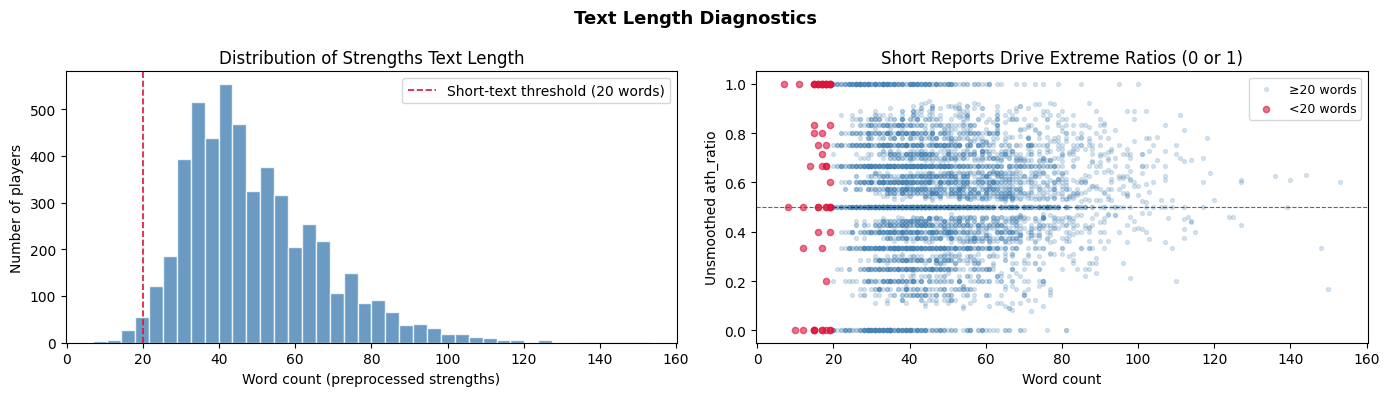

In [49]:
SHORT_TEXT_THRESHOLD = 20

df['word_count'] = df['strengths_preproc'].apply(lambda t: len(t.split()))

print(f'Word count summary across {len(df)} players:')
print(df['word_count'].describe().round(1).to_string())
print(f'\nPlayers with < {SHORT_TEXT_THRESHOLD} words: '
      f'{(df["word_count"] < SHORT_TEXT_THRESHOLD).sum()} '
      f'({(df["word_count"] < SHORT_TEXT_THRESHOLD).mean():.1%})')

short_by_pos = (
    df.groupby('Pos_Group')
    .apply(lambda g: (g['word_count'] < SHORT_TEXT_THRESHOLD).mean())
    .rename('pct_short')
    .sort_values(ascending=False)
)
print(f'\n% players with < {SHORT_TEXT_THRESHOLD} words by position:')
print(short_by_pos.map('{:.1%}'.format).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.hist(df['word_count'], bins=40, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(SHORT_TEXT_THRESHOLD, color='crimson', linestyle='--', linewidth=1.2,
           label=f'Short-text threshold ({SHORT_TEXT_THRESHOLD} words)')
ax.set_xlabel('Word count (preprocessed strengths)')
ax.set_ylabel('Number of players')
ax.set_title('Distribution of Strengths Text Length')
ax.legend()

ax = axes[1]
short_mask = df['word_count'] < SHORT_TEXT_THRESHOLD
ax.scatter(df.loc[~short_mask, 'word_count'], df.loc[~short_mask, 'ath_ratio'],
           alpha=0.2, s=8, color='steelblue', label=f'≥{SHORT_TEXT_THRESHOLD} words')
ax.scatter(df.loc[short_mask, 'word_count'], df.loc[short_mask, 'ath_ratio'],
           alpha=0.6, s=20, color='crimson', zorder=3, label=f'<{SHORT_TEXT_THRESHOLD} words')
ax.axhline(0.5, color='k', linestyle='--', linewidth=0.8, alpha=0.6)
ax.set_xlabel('Word count')
ax.set_ylabel('Unsmoothed ath_ratio')
ax.set_title('Short Reports Drive Extreme Ratios (0 or 1)')
ax.legend(fontsize=9)

plt.suptitle('Text Length Diagnostics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 3c. Smoothing Diagnostic

`ath_ratio_smooth = (talent_hits + α) / (talent_hits + motor_hits + 2α)` with `SMOOTH_ALPHA=1.0`.
The bottom row shows the effect on short-text players only — the spikes at 0 and 1 should collapse toward 0.5.

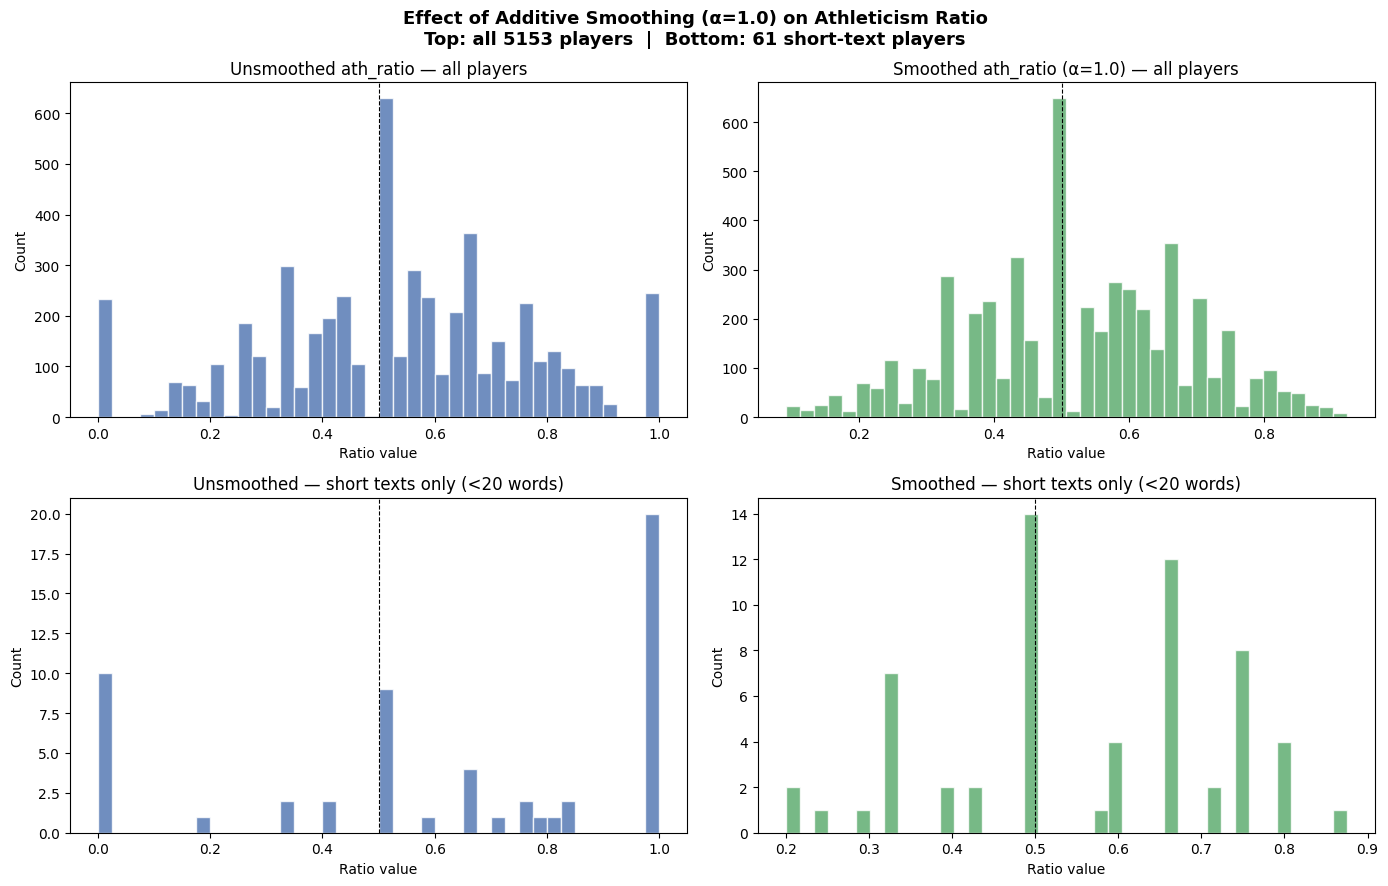

Absolute change |smooth − unsmoothed| by word-count bucket:
            count    mean  median     max
wc_bucket                                
0-10          3.0  0.1500  0.2000  0.2500
11-20        69.0  0.1664  0.1429  0.3333
21-40      1778.0  0.0707  0.0476  0.3333
41-80      2959.0  0.0377  0.0256  0.3333
80+         322.0  0.0229  0.0163  0.3333


In [50]:
short_mask = df['word_count'] < SHORT_TEXT_THRESHOLD

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for ax, col, title, color in [
    (axes[0, 0], 'ath_ratio',        'Unsmoothed ath_ratio — all players',               '#4C72B0'),
    (axes[0, 1], 'ath_ratio_smooth', f'Smoothed ath_ratio (α={SMOOTH_ALPHA}) — all players', '#55A868'),
    (axes[1, 0], 'ath_ratio',        f'Unsmoothed — short texts only (<{SHORT_TEXT_THRESHOLD} words)', '#4C72B0'),
    (axes[1, 1], 'ath_ratio_smooth', f'Smoothed — short texts only (<{SHORT_TEXT_THRESHOLD} words)',    '#55A868'),
]:
    data = df.loc[short_mask, col] if '— short' in title else df[col].dropna()
    ax.hist(data, bins=40, color=color, edgecolor='white', alpha=0.8)
    ax.axvline(0.5, color='k', linestyle='--', linewidth=0.8)
    ax.set_xlabel('Ratio value')
    ax.set_ylabel('Count')
    ax.set_title(title)

plt.suptitle(
    f'Effect of Additive Smoothing (α={SMOOTH_ALPHA}) on Athleticism Ratio\n'
    f'Top: all {len(df)} players  |  Bottom: {short_mask.sum()} short-text players',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

# Where did smoothing change the ratio most?
df['ath_ratio_delta'] = (df['ath_ratio_smooth'] - df['ath_ratio']).abs()
df['wc_bucket'] = pd.cut(df['word_count'], bins=[0, 10, 20, 40, 80, 9999],
                          labels=['0-10', '11-20', '21-40', '41-80', '80+'])
print('Absolute change |smooth − unsmoothed| by word-count bucket:')
print(
    df.groupby('wc_bucket', observed=True)['ath_ratio_delta']
    .describe()[['count', 'mean', '50%', 'max']]
    .rename(columns={'50%': 'median'})
    .round(4)
    .to_string()
)

## 4. Which Positions Get Described as Talent vs. Motor?

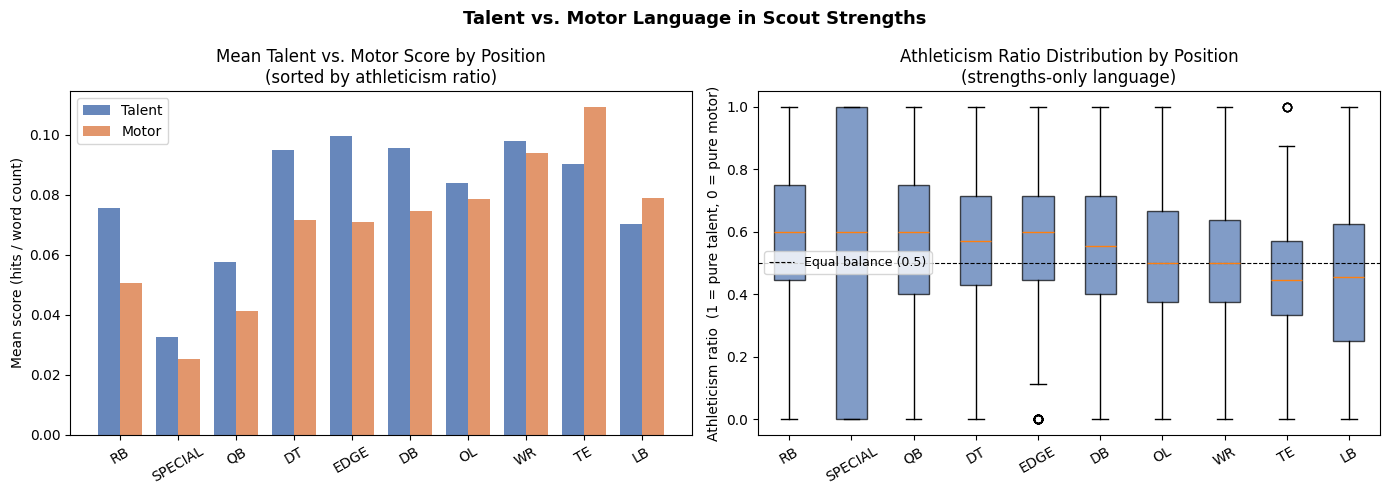


Position summary (sorted by ath_ratio):
           talent_score  motor_score  ath_ratio
Pos_Group                                      
RB               0.0755       0.0505     0.5925
SPECIAL          0.0326       0.0252     0.5802
QB               0.0575       0.0412     0.5769
DT               0.0949       0.0717     0.5663
EDGE             0.0996       0.0709     0.5644
DB               0.0956       0.0747     0.5430
OL               0.0840       0.0787     0.5104
WR               0.0979       0.0940     0.4971
TE               0.0904       0.1091     0.4454
LB               0.0704       0.0788     0.4436


In [51]:
# Compute per-position means, sort by ath_ratio
pos_stats = (
    df.groupby('Pos_Group')[['talent_score', 'motor_score', 'ath_ratio']]
    .mean()
    .sort_values('ath_ratio', ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot A: grouped bar — mean talent vs motor score by position
ax = axes[0]
x  = np.arange(len(pos_stats))
w  = 0.38
ax.bar(x - w/2, pos_stats['talent_score'], width=w, label='Talent', color='#4C72B0', alpha=0.85)
ax.bar(x + w/2, pos_stats['motor_score'],  width=w, label='Motor',  color='#DD8452', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(pos_stats.index, rotation=30)
ax.set_ylabel('Mean score (hits / word count)')
ax.set_title('Mean Talent vs. Motor Score by Position\n(sorted by athleticism ratio)')
ax.legend()

# Plot B: boxplot of ath_ratio by position
ax = axes[1]
order = pos_stats.index.tolist()   # already sorted by mean ath_ratio
data  = [df.loc[df['Pos_Group'] == pos, 'ath_ratio'].dropna().values for pos in order]
bp = ax.boxplot(data, patch_artist=True, widths=0.5)
for patch in bp['boxes']:
    patch.set_facecolor('#4C72B0')
    patch.set_alpha(0.7)
ax.set_xticklabels(order, rotation=30)
ax.axhline(0.5, color='k', linestyle='--', linewidth=0.8, label='Equal balance (0.5)')
ax.set_ylabel('Athleticism ratio  (1 = pure talent, 0 = pure motor)')
ax.set_title('Athleticism Ratio Distribution by Position\n(strengths-only language)')
ax.legend(fontsize=9)

plt.suptitle('Talent vs. Motor Language in Scout Strengths', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nPosition summary (sorted by ath_ratio):')
print(pos_stats.round(4).to_string())

## 5. Cross with Grade

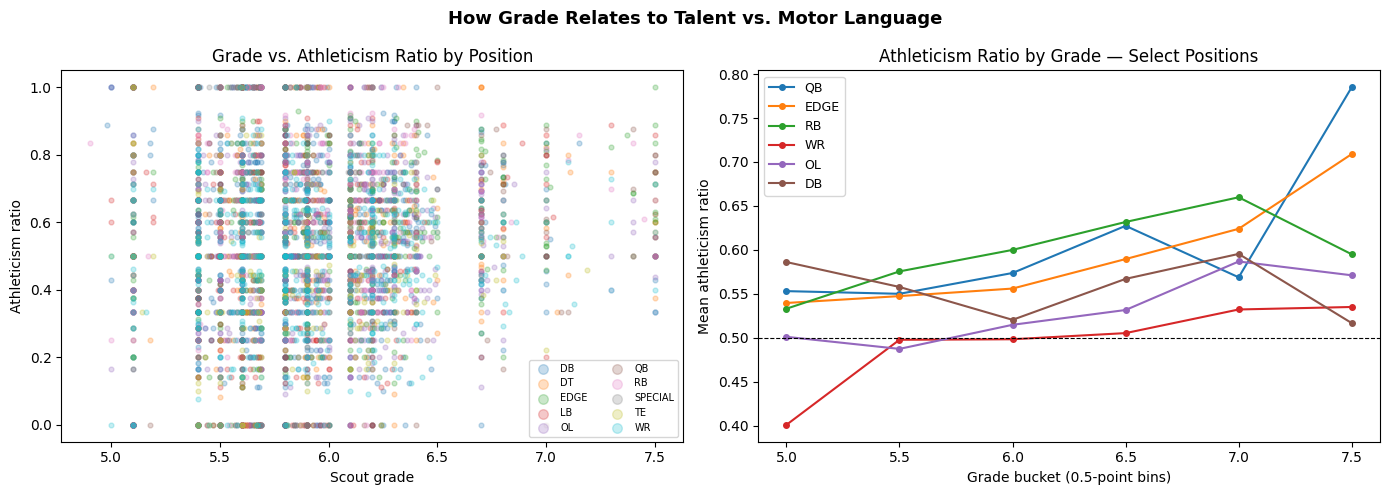

In [52]:
# Bin grades into 0.5-point buckets
df['grade_bin'] = (df['grade'] * 2).round() / 2

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot C: scatter grade vs ath_ratio, coloured by position
ax = axes[0]
colors_map = plt.cm.get_cmap('tab10', df['Pos_Group'].nunique())
for i, (pos, grp) in enumerate(df.groupby('Pos_Group')):
    sub = grp.dropna(subset=['ath_ratio'])
    ax.scatter(sub['grade'], sub['ath_ratio'], alpha=0.25, s=12,
               color=colors_map(i), label=pos)
ax.set_xlabel('Scout grade')
ax.set_ylabel('Athleticism ratio')
ax.set_title('Grade vs. Athleticism Ratio by Position')
ax.legend(fontsize=7, ncol=2, markerscale=2)

# Plot D: mean ath_ratio by grade bucket, line per position group
ax = axes[1]
focus_pos = ['QB', 'EDGE', 'RB', 'WR', 'OL', 'DB']
grade_pos = (
    df[df['Pos_Group'].isin(focus_pos)]
    .groupby(['grade_bin', 'Pos_Group'])['ath_ratio']
    .mean()
    .unstack('Pos_Group')
)
for pos in focus_pos:
    if pos in grade_pos.columns:
        ax.plot(grade_pos.index, grade_pos[pos], marker='o', markersize=4, label=pos)
ax.axhline(0.5, color='k', linestyle='--', linewidth=0.8)
ax.set_xlabel('Grade bucket (0.5-point bins)')
ax.set_ylabel('Mean athleticism ratio')
ax.set_title('Athleticism Ratio by Grade — Select Positions')
ax.legend(fontsize=9)

plt.suptitle('How Grade Relates to Talent vs. Motor Language', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 5b. Athleticism Ratio by Grade — How Each Position Changed Across Year Bins

Same x-axis (grade bucket) as above, but each line is a **3-year bin** within a position.
Darker = more recent. Uses the full 2010–2026 data (no year filter). Shows whether the talent-vs-motor balance for a given grade level has shifted over time.

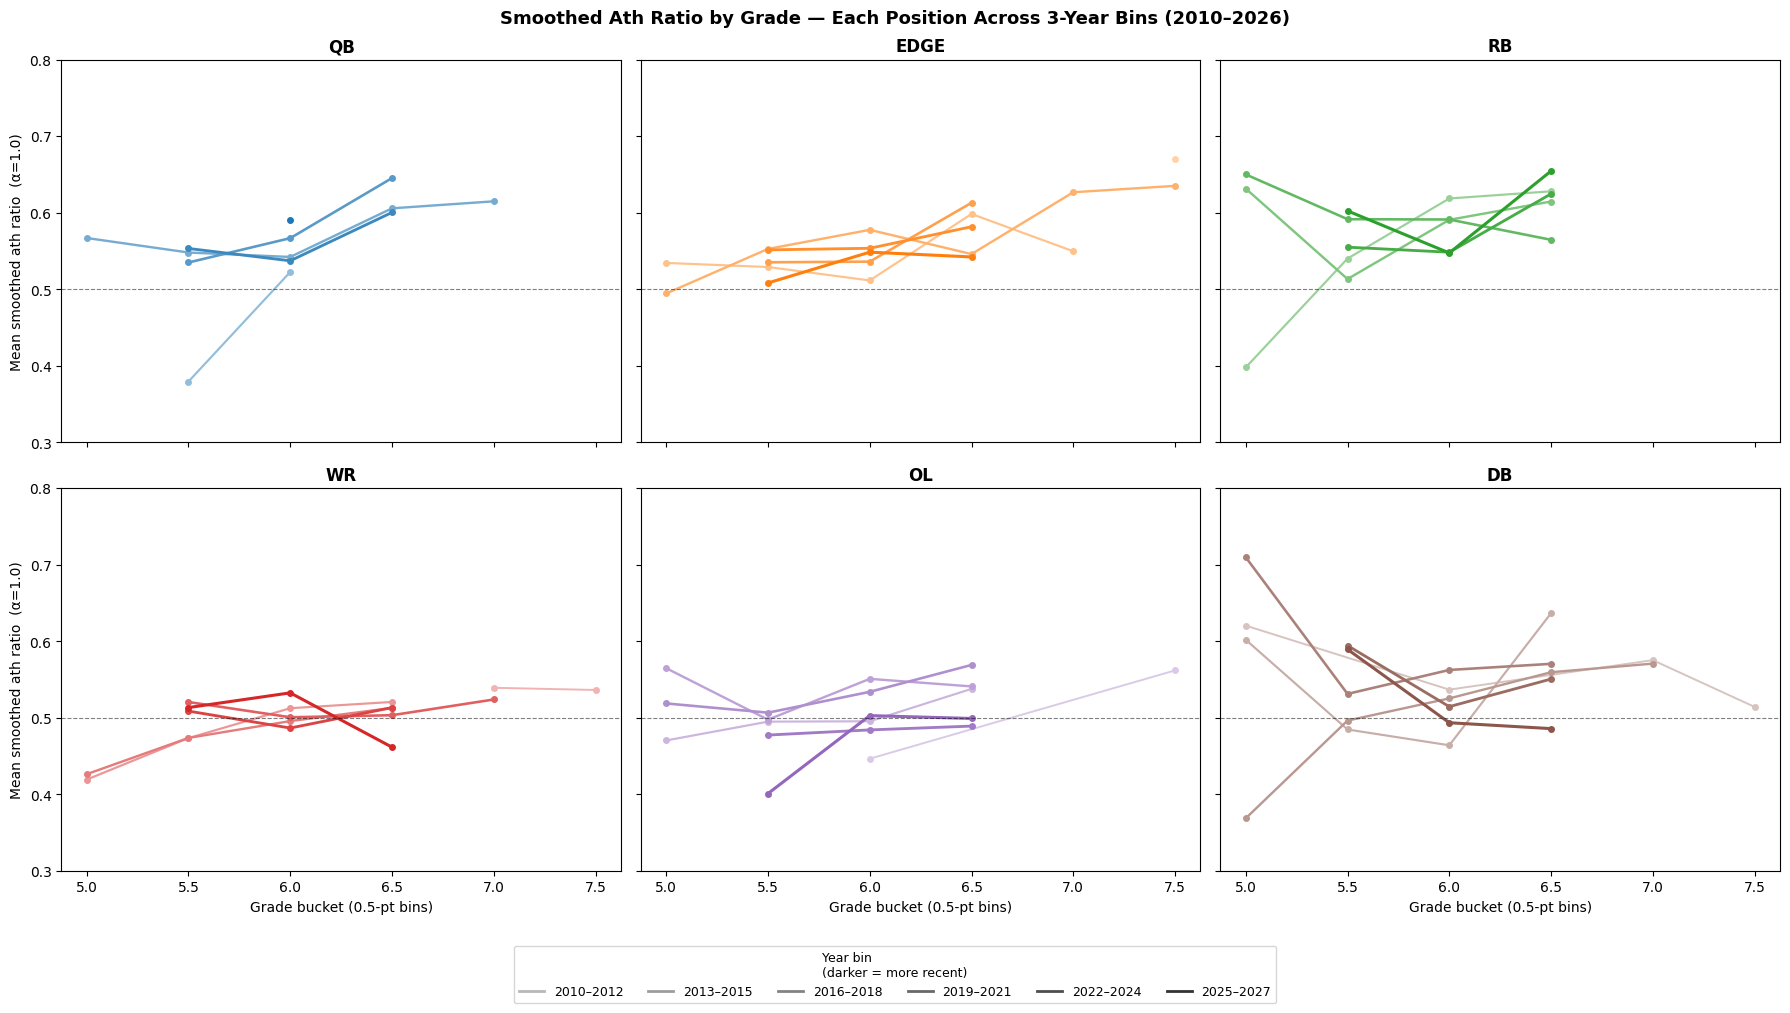

In [53]:
import matplotlib.colors as mcolors

# ── Load full year range (no year filter) ─────────────────────────────────────
df_full = pd.read_csv('../data/processed/draft_enriched_with_contracts.csv')
df_full = df_full[df_full['grade'] <= GRADE_MAX].copy()
df_full = df_full.dropna(subset=[TARGET, 'grade', 'Pos_Group', 'strengths']).copy()
df_full[TARGET] = df_full[TARGET].astype(int)
df_full['strengths_preproc'] = df_full['strengths'].apply(preprocess)
df_full = df_full[df_full['strengths_preproc'] != ''].copy().reset_index(drop=True)

df_full['talent_hits'] = df_full['strengths_preproc'].apply(lambda t: count_hits(t, TALENT_WORDS))
df_full['motor_hits']  = df_full['strengths_preproc'].apply(lambda t: count_hits(t, MOTOR_WORDS))
denom = df_full['talent_hits'] + df_full['motor_hits'] + 2 * SMOOTH_ALPHA
df_full['ath_ratio_smooth'] = (df_full['talent_hits'] + SMOOTH_ALPHA) / denom

df_full['grade_bin'] = (df_full['grade'] * 2).round() / 2

# ── 3-year bins 2010–2026 ────────────────────────────────────────────────────
bin_edges  = list(range(2009, 2028, 3))   # 2009, 2012, 2015, 2018, 2021, 2024, 2027
bin_labels = [f'{s+1}–{s+3}' for s in bin_edges[:-1]]   # 2010–2012, 2013–2015, …
df_full['year_bin'] = pd.cut(df_full['year'], bins=bin_edges, labels=bin_labels)

valid_bins = [b for b in bin_labels if df_full['year_bin'].eq(b).any()]
n_bins = len(valid_bins)

# ── Colors: same base per position, lightest → darkest = oldest → newest ─────
focus_pos  = ['QB', 'EDGE', 'RB', 'WR', 'OL', 'DB']
cycle_colors = [p['color'] for p in plt.rcParams['axes.prop_cycle']]
pos_base_color = {pos: cycle_colors[i] for i, pos in enumerate(focus_pos)}

def lighten(color, amount):
    """Mix color with white; amount=0 → original, amount=1 → white."""
    r, g, b = mcolors.to_rgb(color)
    return (1 - (1-r)*(1-amount), 1 - (1-g)*(1-amount), 1 - (1-b)*(1-amount))

lighten_amounts = [0.65 - i * (0.65 / max(n_bins - 1, 1)) for i in range(n_bins)]
# e.g. 4 bins → [0.65, 0.43, 0.22, 0.0] → oldest=lightest, newest=original color

MIN_CELL = 5   # minimum players in a grade_bin × year_bin cell

fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharey=True, sharex=True)

for ax, pos in zip(axes.flat, focus_pos):
    base = pos_base_color[pos]
    for i, ybin in enumerate(valid_bins):
        sub = df_full[(df_full['Pos_Group'] == pos) & (df_full['year_bin'] == ybin)]
        trend = (
            sub.groupby('grade_bin')['ath_ratio_smooth']
            .agg(['mean', 'count'])
            .rename(columns={'mean': 'ratio', 'count': 'n'})
        )
        trend = trend[trend['n'] >= MIN_CELL]
        if trend.empty:
            continue
        color = lighten(base, lighten_amounts[i])
        lw    = 1.4 + i * (0.8 / max(n_bins - 1, 1))   # thicker = more recent
        ax.plot(trend.index, trend['ratio'],
                marker='o', markersize=4, linewidth=lw,
                color=color, label=ybin)

    ax.axhline(0.5, color='k', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.set_title(pos, fontweight='bold', fontsize=12)
    ax.set_ylim(0.3, 0.8)
    ax.yaxis.set_major_locator(mticker.MultipleLocator(0.1))

for ax in axes[1]:
    ax.set_xlabel('Grade bucket (0.5-pt bins)')
for ax in axes[:, 0]:
    ax.set_ylabel(f'Mean smoothed ath ratio  (α={SMOOTH_ALPHA})')

# Shared legend (year bins, darkest last)
handles = [
    plt.Line2D([0], [0], color=lighten('#333333', lighten_amounts[i]),
               linewidth=2, label=ybin)
    for i, ybin in enumerate(valid_bins)
]
fig.legend(handles=handles, title='Year bin\n(darker = more recent)',
           loc='lower center', ncol=n_bins, fontsize=9, title_fontsize=9,
           bbox_to_anchor=(0.5, -0.02))

fig.suptitle('Smoothed Ath Ratio by Grade — Each Position Across 3-Year Bins (2010–2026)',
             fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()

## 6. Cross with Contract Outcome

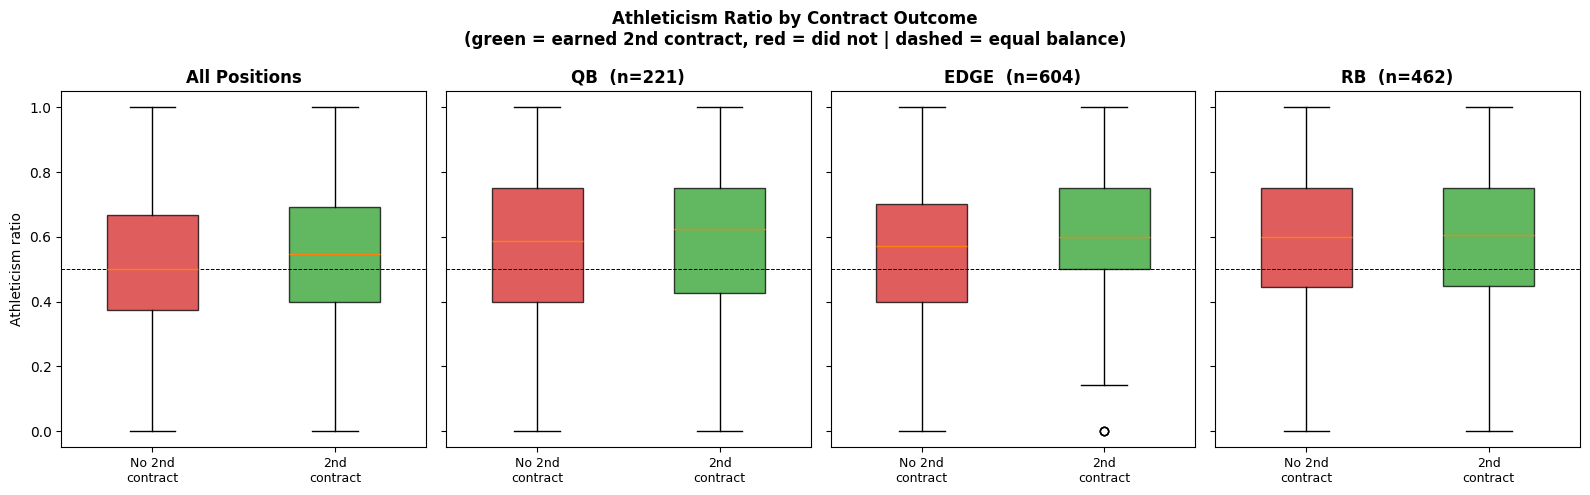

In [54]:
FOCUS = ['QB', 'EDGE', 'RB']
fig, axes = plt.subplots(1, 4, figsize=(16, 5), sharey=True)

outcome_labels = {0: 'No 2nd contract', 1: '2nd contract'}
colors = {0: '#d62728', 1: '#2ca02c'}

# Overall
ax = axes[0]
data = [df.loc[df[TARGET] == v, 'ath_ratio'].dropna().values for v in [0, 1]]
bp = ax.boxplot(data, patch_artist=True, widths=0.5)
for patch, v in zip(bp['boxes'], [0, 1]):
    patch.set_facecolor(colors[v])
    patch.set_alpha(0.75)
ax.set_xticklabels(['No 2nd\ncontract', '2nd\ncontract'], fontsize=9)
ax.set_title('All Positions', fontweight='bold')
ax.set_ylabel('Athleticism ratio')
ax.axhline(0.5, color='k', linestyle='--', linewidth=0.7)

# Per position
for ax, pos in zip(axes[1:], FOCUS):
    sub = df[df['Pos_Group'] == pos]
    data = [sub.loc[sub[TARGET] == v, 'ath_ratio'].dropna().values for v in [0, 1]]
    bp = ax.boxplot(data, patch_artist=True, widths=0.5)
    for patch, v in zip(bp['boxes'], [0, 1]):
        patch.set_facecolor(colors[v])
        patch.set_alpha(0.75)
    ax.set_xticklabels(['No 2nd\ncontract', '2nd\ncontract'], fontsize=9)
    ax.set_title(f'{pos}  (n={len(sub)})', fontweight='bold')
    ax.axhline(0.5, color='k', linestyle='--', linewidth=0.7)

fig.suptitle('Athleticism Ratio by Contract Outcome\n'
             '(green = earned 2nd contract, red = did not | dashed = equal balance)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [55]:
# Summary table: mean talent%, motor%, ath_ratio by position × outcome
tbl = (
    df.groupby(['Pos_Group', TARGET])[['talent_score', 'motor_score', 'ath_ratio']]
    .mean()
    .round(4)
)
tbl.index = tbl.index.set_levels(
    tbl.index.get_level_values(1).map({0: 'No 2nd contract', 1: '2nd contract'}),
    level=1
)
tbl.columns = ['Talent score', 'Motor score', 'Ath ratio']

# Also show the difference in ath_ratio between outcomes
diff = (
    tbl['Ath ratio']
    .unstack(TARGET)
    .assign(delta=lambda x: x.get('2nd contract', 0) - x.get('No 2nd contract', 0))
    .sort_values('delta', ascending=False)
)

print('Mean scores by position and outcome:')
print(tbl.to_string())
print('\nAth ratio delta (2nd contract − no 2nd contract) by position:')
print(diff.round(4).to_string())

ValueError: Level values must be unique: ['No 2nd contract', '2nd contract', 'No 2nd contract', '2nd contract', 'No 2nd contract', '2nd contract', 'No 2nd contract', '2nd contract', 'No 2nd contract', '2nd contract', 'No 2nd contract', '2nd contract', 'No 2nd contract', '2nd contract', 'No 2nd contract', '2nd contract', 'No 2nd contract', '2nd contract', 'No 2nd contract', '2nd contract'] on level 1

## 7. Key Findings

*(Fill in after running — template below)*

**Position language patterns:**
- Positions described most in talent/athletic terms in strengths: …
- Positions described most in motor/technique terms: …
- Most consistent (narrow ath_ratio IQR): …
- Most mixed (wide IQR): …

**Grade relationship:**
- Higher grades are associated with [more/less/no change in] athleticism-dominant language
- Position-specific patterns: …

**Contract outcome:**
- Overall: players who earned a 2nd contract were described with [higher/lower/equal] ath_ratio
- QB: …
- EDGE: …
- RB: …
- Interpretation: …

## 8. Athleticism Ratio Over Time by Position

Two panels:
- **All players** — how the talent vs. motor balance in each position's strengths language has shifted year over year
- **High-grade players only (grade ≥ 6.0)** — same trend but restricted to players scouts rated highly, filtering out marginal prospects who may skew the language

If a position's ath_ratio is rising over time, scouts are describing that position's strengths increasingly in athletic terms. A falling ratio means technique/character language is taking over.

In [ ]:
HIGH_GRADE_THRESHOLD = 6.0
MIN_PLAYERS_PER_CELL = 5   # drop year×position cells with fewer players (too noisy)

pos_order = (
    df.groupby('Pos_Group')['ath_ratio_smooth']
    .median()
    .dropna()
    .sort_values(ascending=False)
    .index.tolist()
)
colors = plt.cm.tab10.colors
color_map = {pos: colors[i % 10] for i, pos in enumerate(pos_order)}

def yearly_ratio(data, min_n=MIN_PLAYERS_PER_CELL):
    """Mean ath_ratio_smooth per year×position, masking cells with < min_n players."""
    out = (
        data.dropna(subset=['ath_ratio_smooth'])
        .groupby(['year', 'Pos_Group'])
        .agg(mean_ratio=('ath_ratio_smooth', 'mean'), n=('ath_ratio_smooth', 'count'))
        .reset_index()
    )
    out.loc[out['n'] < min_n, 'mean_ratio'] = np.nan
    return out

all_trend  = yearly_ratio(df)
high_trend = yearly_ratio(df[df['grade'] >= HIGH_GRADE_THRESHOLD])

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
titles = [
    f'All players  (n={len(df)})',
    f'High-grade only  (grade ≥ {HIGH_GRADE_THRESHOLD},  '
    f'n={len(df[df["grade"] >= HIGH_GRADE_THRESHOLD])})',
]

for ax, trend_df, title in zip(axes, [all_trend, high_trend], titles):
    for pos in pos_order:
        sub = trend_df[trend_df['Pos_Group'] == pos].sort_values('year')
        valid = sub.dropna(subset=['mean_ratio'])
        if valid.empty:
            continue
        ax.plot(
            valid['year'], valid['mean_ratio'],
            marker='o', markersize=4, linewidth=1.8,
            color=color_map[pos], label=pos, alpha=0.85,
        )

    ax.axhline(0.5, color='k', linestyle='--', linewidth=0.8, alpha=0.5,
               label='Equal balance (0.5)')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Draft year')
    ax.set_xticks(sorted(df['year'].unique()))
    ax.tick_params(axis='x', rotation=45)
    ax.set_ylim(0, 1)
    if ax == axes[0]:
        ax.set_ylabel(f'Mean smoothed athleticism ratio  (α={SMOOTH_ALPHA})\n'
                      '(1 = pure talent, 0 = pure motor)')
    ax.legend(fontsize=8, ncol=2, loc='upper right')

fig.suptitle('Smoothed Athleticism Ratio Over Time by Position Group', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Athleticism Ratio Over Time by Position Group

Uses the `Group` column from the data directly. Tracks the talent-vs-motor balance year over year for each group.

| Group | Description |
|-------|-------------|
| SKILL O | Offensive skill (WR, RB, TE) |
| COMBO O | Dual-role offensive (FB, H-back, etc.) |
| BIG O | Offensive line |
| QB | Quarterback |
| SKILL D | Defensive backs, slot coverage |
| COMBO D | Linebackers, hybrid defenders |
| BIG D | Defensive line, EDGE |
| SPECIAL | Special teams |

In [ ]:
GROUP_ORDER = ['SKILL O', 'COMBO O', 'BIG O', 'QB', 'SKILL D', 'COMBO D', 'BIG D', 'SPECIAL']
GROUP_COLORS = {
    'SKILL O': '#4C72B0',
    'COMBO O': '#729ECE',
    'BIG O':   '#55A868',
    'QB':      '#8172B2',
    'SKILL D': '#C44E52',
    'COMBO D': '#E07070',
    'BIG D':   '#937860',
    'SPECIAL': '#AAAAAA',
}

def yearly_ratio_broad(data, group_col='Group', min_n=MIN_PLAYERS_PER_CELL):
    out = (
        data.dropna(subset=['ath_ratio_smooth', group_col])
        .groupby(['year', group_col])
        .agg(mean_ratio=('ath_ratio_smooth', 'mean'), n=('ath_ratio_smooth', 'count'))
        .reset_index()
    )
    out.loc[out['n'] < min_n, 'mean_ratio'] = np.nan
    return out

all_broad  = yearly_ratio_broad(df)
high_broad = yearly_ratio_broad(df[df['grade'] >= HIGH_GRADE_THRESHOLD])

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
titles = [
    f'All players  (n={len(df)})',
    f'High-grade only  (grade ≥ {HIGH_GRADE_THRESHOLD},  '
    f'n={len(df[df["grade"] >= HIGH_GRADE_THRESHOLD])})',
]

for ax, trend_df, title in zip(axes, [all_broad, high_broad], titles):
    for grp in GROUP_ORDER:
        sub = trend_df[trend_df['Group'] == grp].sort_values('year')
        valid = sub.dropna(subset=['mean_ratio'])
        if valid.empty:
            continue
        ax.plot(
            valid['year'], valid['mean_ratio'],
            marker='o', markersize=5, linewidth=2.2,
            color=GROUP_COLORS[grp], label=grp,
        )

    ax.axhline(0.5, color='k', linestyle='--', linewidth=0.8, alpha=0.5,
               label='Equal balance (0.5)')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Draft year')
    ax.set_xticks(sorted(df['year'].unique()))
    ax.tick_params(axis='x', rotation=45)
    ax.set_ylim(0, 1)
    if ax == axes[0]:
        ax.set_ylabel(f'Mean smoothed athleticism ratio  (α={SMOOTH_ALPHA})\n'
                      '(1 = pure talent, 0 = pure motor)')
    ax.legend(fontsize=9, loc='upper right')

fig.suptitle('Smoothed Athleticism Ratio Over Time — Broad Position Groups', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

pivot = (
    df.dropna(subset=['ath_ratio_smooth', 'Group'])
    .groupby(['Group', 'year'])['ath_ratio_smooth']
    .mean()
    .unstack('year')
    .reindex(GROUP_ORDER)
    .round(3)
)
print('Mean ath_ratio_smooth by Group and year:')
print(pivot.to_string())